# Setup

In [1]:
# !git clone https://github.com/IgnacioOQ/e_network_inequality
!git clone -b ai-agents-branch https://github.com/IgnacioOQ/e_network_inequality

Cloning into 'e_network_inequality'...
remote: Enumerating objects: 1465, done.
remote: Counting objects: 100% (538/538), done.
remote: Compressing objects: 100% (332/332), done.
remote: Total 1465 (delta 256), reused 281 (delta 201), pack-reused 927 (from 2)
Receiving objects: 100% (1465/1465), 37.79 MiB | 53.45 MiB/s, done.
Resolving deltas: 100% (900/900), done.


In [2]:
!pip install dill

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 6.4 MB/s eta 0:00:00


In [3]:
%cd e_network_inequality

/content/e_network_inequality


In [4]:
from imports import *
from agents import BetaAgent, BayesAgent
from model import Model
from network_utils import *
# notice this is not network_utilsv2
from network_generation import *
from simulation_functions import *
from vectorized_simulation_functions import *
from functools import partial
import hashlib
import gc
from multiprocessing import get_context

ModuleNotFoundError: No module named 'imports'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

dumping_path = '/content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/ignacio_playground/'
print("Current Directory:", dumping_path)

# Simulation Functions

## Parameter Generation

In [ ]:
# --- Start of Provided Code ---

def generate_parameters_here(_,G,method='randomization'):
    """
    Generates parameters for a single simulation run, including network modification.
    """
    process_seed = int.from_bytes(os.urandom(4), byteorder='little')
    rd.seed(process_seed)

    # Randomly sample parameters for this group
    uncertainty = rd.uniform(.000001, .001)
    n_experiments = rd.randint(1000, 10000)

    # now we pick a random number
    # Re-instating the 1/3 limit as a potential fix for the
    # "Sample larger than population" ValueError seen in `equalize`.
    # This caps the number of edges to be modified.
    proportion_edges = rd.random() * (1/3)

    # Do randomization

    num_edges = G.number_of_edges()
    modified_network = G.copy() # Default to a copy

    if method == 'randomization':
      num_edges_to_randomize = int(num_edges * proportion_edges)
      modified_network = randomize_network(G, n_edges=num_edges_to_randomize)
    elif method == 'equalize':
      num_edges_to_randomize = int(num_edges * proportion_edges)
      modified_network = equalize(G, num_edges_to_randomize)
    elif method == 'densify':
      num_edges_to_add = int(num_edges * proportion_edges)
      modified_network = densify_fancy_speed_up(G,num_edges_to_add,target_degree_dist='original',keep_density_fixed=False)
    elif method == 'densify_fixed':
      num_edges_to_add = int(num_edges * proportion_edges)
      modified_network = densify_fancy_speed_up(G,num_edges_to_add,target_degree_dist='uniform',keep_density_fixed=True)
    elif method =='cluster':
      num_edges_to_add = int(num_edges * proportion_edges)
      modified_network = cluster_network(G,num_edges_to_add)
    elif method =='decluster':
      num_edges_to_randomize = int(num_edges * proportion_edges)
      modified_network = decluster_network(G,num_keys_to_randomize)
    else:
      print(f"Warning: Method '{method}' not recognized. No network modification applied.")

    result = generate_parameters_aggregate(modified_network, uncertainty=uncertainty, n_experiments=n_experiments,
                                           p_rewiring=proportion_edges)
    result['uncertainty'] = uncertainty
    result['n_experiments'] = n_experiments
    result['proportion_edges'] = proportion_edges
    # result['parameter_random_seed']= process_seed
    return result

## Non-Vectorized Simulations Method

In [ ]:
# PARAMETERS

# Define the path for saving results
dumping_path = '/content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/ignacio_playground/'
methods = ['randomization'] # Kept only randomization as requested

# --- Define Network Parameters ---
# Moved to global scope so main() and plotting loop can access them
n_sizes = [100] # Example sizes

# ER parameters
er_p_values = [0.05]    # Example probabilities

# WS parameters (k = initial neighbors, p = rewiring prob)
ws_k_values = [4, 6] # k must be even
ws_p_values = [0.01, 0.1]

# BA parameters (m = edges to attach from new node)
ba_m_values = [2, 4]

In [ ]:
def run_nonvect_method(method, G_default, num_cores, n_simulations, network_name_prefix, combine_results=False,agent_type='bayes'):
    """
    Runs the full parameter generation and simulation pipeline for a single method
    on a given network.

    Args:
        method (str): The network modification method to test.
        G_default (nx.Graph): The base network to modify.
        num_cores (int): Number of CPU cores for pooling.
        n_simulations (int): Number of simulation runs.
        network_name_prefix (str): Base name for the network (e.g., "er_n100_p0.05").
        combine_results (bool): If True, append to existing results. If False, overwrite.
    """
    # print(f'Running stuff for method: {method}')

    # ─── Generate parameters ───
    # print('Generating parameters...')
    generate_params = partial(generate_parameters_here, G=G_default, method=method)

    param_dict = []
    try:
        with Pool(num_cores) as pool:
            param_dict = list(tqdm.tqdm(
                pool.imap_unordered(generate_params, range(n_simulations)),
                total=n_simulations,
                desc=f"Generating params for {method}"
            ))
    except Exception as e:
        print(f"Error during parameter generation pool for method {method}: {e}")
        return # Skip this method if param generation fails

    if not param_dict:
        print(f"No parameters generated for method {method}. Skipping simulation.")
        return

    # ─── Run simulations ───
    # print('Running simulations...')
    run_simulation_wrapper = partial(run_simulation_with_params, tolerance=1e-5,tstep_stopping=True,agent_type=agent_type)

    simulation_results = []
    try:
        with Pool(num_cores) as pool:
            simulation_results = list(tqdm.tqdm(
                pool.imap_unordered(run_simulation_wrapper, param_dict),
                total=len(param_dict),
                desc=f"Running simulations for {method}"
            ))
    except Exception as e:
        print(f"Error during simulation pool for method {method}: {e}")
        # Continue to save any results that might have completed if possible
        # but in this imap setup, it's all-or-nothing.
        simulation_results = [r for r in simulation_results if r is not None] # Filter out potential Nones
        if not simulation_results:
            print("No simulation results to save.")
            return

    # ─── Save results ───
    # print('Saving results...')
    # Update results_path to use the generalized network_name_prefix
    results_path = dumping_path + f"{network_name_prefix}_results_{method}.csv"
    new_results_df = pd.DataFrame(simulation_results)

    try:
        if os.path.exists(results_path) and combine_results:
            # print(f"Appending to existing results file: {results_path}")
            existing_results_df = pd.read_csv(results_path)
            combined_results_df = pd.concat([existing_results_df, new_results_df], ignore_index=True)
        else:
            # print(f"Creating new results file: {results_path}")
            combined_results_df = new_results_df

        combined_results_df.to_csv(results_path, index=False)
        print(f"Total results for {method} ({network_name_prefix}): {len(combined_results_df)}")

    except pd.errors.EmptyDataError:
        print(f"Warning: Existing results file {results_path} was empty. Overwriting.")
        new_results_df.to_csv(results_path, index=False)
        print(f"Total results for {method} ({network_name_prefix}): {len(new_results_df)}")
    except Exception as e:
        print(f"Error saving results to {results_path}: {e}")

In [ ]:
def nonvect_main(combine_results=False,agent_type='bayes',n_simulations = 100):
    """
    Main function to generate networks, run simulations, and save results.
    This version iterates over different network parameters (size, probability)
    for Erdős-Rényi, Watts-Strogatz, and Barabasi-Albert graphs.
    """

    try:
        num_cores = cpu_count()  # Get the number of available CPU cores
    except NotImplementedError:
        print("Warning: Could not determine number of cores. Defaulting to 1.")
        num_cores = 1

    print(f"Number of cores: {num_cores}")

    # n_simulations = 4800 # User set this to 100
    # methods = ['randomization']

    # --- Loop 1: Erdős-Rényi ---
    for n in n_sizes:
        for p in er_p_values:
            network_name_prefix = f"er_n{n}_p{p:.2f}"
            print(f"\n--- Starting simulations for ER Network: {network_name_prefix} ---")

            # Generate the network
            # nx.erdos_renyi_graph creates 0-indexed nodes, so no relabeling is needed
            # Added directed=True as requested.
            G_default = nx.erdos_renyi_graph(n, p, directed=True)

            # n_agents = G_default.number_of_nodes()
            # print(f"Number of agents: {n_agents}")

            # Run all modification methods for this single generated network
            for method in methods:
                run_nonvect_method(method, G_default, num_cores, n_simulations, network_name_prefix,combine_results=combine_results,agent_type=agent_type)

    # --- Loop 2: Watts-Strogatz (Small World) ---
    # for n in n_sizes:
    #     for k in ws_k_values:
    #         if k >= n: continue # k must be < n
    #         for p in ws_p_values:
    #             network_name_prefix = f"ws_n{n}_k{k}_p{p:.2f}"
    #             print(f"\n--- Starting simulations for WS Network: {network_name_prefix} ---")

    #             # Create undirected, then convert to directed
    #             G_ws_undirected = nx.watts_strogatz_graph(n, k, p)
    #             G_default = G_ws_undirected.to_directed()

    #             for method in methods:
    #                 run_method(method, G_default, num_cores, n_simulations, network_name_prefix,combine_results=combine_results,agent_type=agent_type)

    # --- Loop 3: Barabasi-Albert (Preferential Attachment) ---
    # for n in n_sizes:
    #     for m in ba_m_values:
    #         if m >= n: continue # m must be < n
    #         network_name_prefix = f"ba_n{n}_m{m}"
    #         print(f"\n--- Starting simulations for BA Network: {network_name_prefix} ---")

    #         # Create undirected, then convert to directed
    #         G_ba_undirected = nx.barabasi_albert_graph(n, m)
    #         G_default = G_ba_undirected.to_directed()

    #         for method in methods:
    #             run_method(method, G_default, num_cores, n_simulations, network_name_prefix,combine_results=combine_results,agent_type=agent_type)

## Vectorized Simulation Methods

In [ ]:
# PARAMETERS

# Define the path for saving results
dumping_path = '/content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/ignacio_playground/'
methods = ['randomization'] # Kept only randomization as requested

# --- Define Network Parameters ---
# Moved to global scope so main() and plotting loop can access them
n_sizes = [200] # Example sizes

# ER parameters
er_p_values = [0.01]    # Example probabilities

# WS parameters (k = initial neighbors, p = rewiring prob)
ws_k_values = [4, 6] # k must be even
ws_p_values = [0.01, 0.1]

# BA parameters (m = edges to attach from new node)
ba_m_values = [2, 4]

In [ ]:
def run_vect_method(method, G_default, num_cores, n_simulations, network_name_prefix, combine_results=False,agent_type='bayes', master_seed=20260516):
    """
    Runs the full parameter generation and simulation pipeline for a single method
    on a given network.

    Args:
        method (str): The network modification method to test.
        G_default (nx.Graph): The base network to modify.
        num_cores (int): Number of CPU cores for pooling.
        n_simulations (int): Number of simulation runs.
        network_name_prefix (str): Base name for the network (e.g., "er_n100_p0.05").
        combine_results (bool): If True, append to existing results. If False, overwrite.
        master_seed (int): Per-run child seeds derive from this via SeedSequence.spawn
            for statistical independence and reproducibility; each seed is also
            logged in result_dict by run_vectorized_simulation_with_params.
    """
    # print(f'Running stuff for method: {method}')

    # ─── Generate parameters ───
    # print('Generating parameters...')
    generate_params = partial(generate_parameters_here, G=G_default, method=method)

    param_dict = []
    try:
        with Pool(num_cores) as pool:
            param_dict = list(tqdm.tqdm(
                pool.imap_unordered(generate_params, range(n_simulations)),
                total=n_simulations,
                desc=f"Generating params for {method}"
            ))
    except Exception as e:
        print(f"Error during parameter generation pool for method {method}: {e}")
        return # Skip this method if param generation fails

    if not param_dict:
        print(f"No parameters generated for method {method}. Skipping simulation.")
        return

    # ─── Assign per-job simulation seeds ───
    from numpy.random import SeedSequence
    child_seeds = [int(s.generate_state(1)[0])
                   for s in SeedSequence(master_seed).spawn(len(param_dict))]
    for pd_, cs in zip(param_dict, child_seeds):
        pd_["seed"] = cs

    # ─── Run simulations ───
    # print('Running simulations...')
    run_simulation_wrapper = partial(run_vectorized_simulation_with_params, tolerance=1e-5,tstep_stopping=True,agent_type=agent_type)

    simulation_results = []
    try:
        with Pool(num_cores) as pool:
            simulation_results = list(tqdm.tqdm(
                pool.imap_unordered(run_simulation_wrapper, param_dict),
                total=len(param_dict),
                desc=f"Running simulations for {method}"
            ))
    except Exception as e:
        print(f"Error during simulation pool for method {method}: {e}")
        # Continue to save any results that might have completed if possible
        # but in this imap setup, it's all-or-nothing.
        simulation_results = [r for r in simulation_results if r is not None] # Filter out potential Nones
        if not simulation_results:
            print("No simulation results to save.")
            return

    # ─── Save results ───
    # print('Saving results...')
    # Update results_path to use the generalized network_name_prefix
    results_path = dumping_path + f"vectorized_{network_name_prefix}_results_{method}.csv"
    new_results_df = pd.DataFrame(simulation_results)

    try:
        if os.path.exists(results_path) and combine_results:
            # print(f"Appending to existing results file: {results_path}")
            existing_results_df = pd.read_csv(results_path)
            combined_results_df = pd.concat([existing_results_df, new_results_df], ignore_index=True)
        else:
            # print(f"Creating new results file: {results_path}")
            combined_results_df = new_results_df

        combined_results_df.to_csv(results_path, index=False)
        print(f"Total results for {method} ({network_name_prefix}): {len(combined_results_df)}")

    except pd.errors.EmptyDataError:
        print(f"Warning: Existing results file {results_path} was empty. Overwriting.")
        new_results_df.to_csv(results_path, index=False)
        print(f"Total results for {method} ({network_name_prefix}): {len(new_results_df)}")
    except Exception as e:
        print(f"Error saving results to {results_path}: {e}")

In [ ]:
def vect_main(combine_results=False,agent_type='bayes',n_simulations = 100):
    """
    Main function to generate networks, run simulations, and save results.
    This version iterates over different network parameters (size, probability)
    for Erdős-Rényi, Watts-Strogatz, and Barabasi-Albert graphs.
    """

    try:
        num_cores = cpu_count()  # Get the number of available CPU cores
    except NotImplementedError:
        print("Warning: Could not determine number of cores. Defaulting to 1.")
        num_cores = 1

    print(f"Number of cores: {num_cores}")

    # n_simulations = 4800 # User set this to 100
    # methods = ['randomization']

    # --- Loop 1: Erdős-Rényi ---
    for n in n_sizes:
        for p in er_p_values:
            network_name_prefix = f"er_n{n}_p{p:.2f}"
            print(f"\n--- Starting simulations for ER Network: {network_name_prefix} ---")

            # Generate the network
            # nx.erdos_renyi_graph creates 0-indexed nodes, so no relabeling is needed
            # Added directed=True as requested.
            G_default = nx.erdos_renyi_graph(n, p, directed=True)

            # n_agents = G_default.number_of_nodes()
            # print(f"Number of agents: {n_agents}")

            # Run all modification methods for this single generated network
            for method in methods:
                run_vect_method(method, G_default, num_cores, n_simulations, network_name_prefix,combine_results=combine_results,agent_type=agent_type)

    # --- Loop 2: Watts-Strogatz (Small World) ---
    # for n in n_sizes:
    #     for k in ws_k_values:
    #         if k >= n: continue # k must be < n
    #         for p in ws_p_values:
    #             network_name_prefix = f"ws_n{n}_k{k}_p{p:.2f}"
    #             print(f"\n--- Starting simulations for WS Network: {network_name_prefix} ---")

    #             # Create undirected, then convert to directed
    #             G_ws_undirected = nx.watts_strogatz_graph(n, k, p)
    #             G_default = G_ws_undirected.to_directed()

    #             for method in methods:
    #                 run_method(method, G_default, num_cores, n_simulations, network_name_prefix,combine_results=combine_results,agent_type=agent_type)

    # --- Loop 3: Barabasi-Albert (Preferential Attachment) ---
    # for n in n_sizes:
    #     for m in ba_m_values:
    #         if m >= n: continue # m must be < n
    #         network_name_prefix = f"ba_n{n}_m{m}"
    #         print(f"\n--- Starting simulations for BA Network: {network_name_prefix} ---")

    #         # Create undirected, then convert to directed
    #         G_ba_undirected = nx.barabasi_albert_graph(n, m)
    #         G_default = G_ba_undirected.to_directed()

    #         for method in methods:
    #             run_method(method, G_default, num_cores, n_simulations, network_name_prefix,combine_results=combine_results,agent_type=agent_type)

## Plotting

In [ ]:
def run_plotting(vectorized=False):
    """
    Loops through all network parameters and methods, loading results
    and generating scatter plots.
    """
    print("\n--- Starting Plotting Phase ---")

    # Since methods is just ['randomization'], we can just use methods[0]
    # If you add more methods later, you'll need to nest this loop.
    if not methods:
        print("No methods specified. Skipping plotting.")
        return

    method = methods[0]

    # --- Plot Loop 1: Erdős-Rényi ---
    for n in n_sizes:
        for p in er_p_values:
            network_name_prefix = f"er_n{n}_p{p:.2f}"
            if vectorized:
              results_path = dumping_path + f"vectorized_{network_name_prefix}_results_{method}.csv"
            else:
              results_path = dumping_path + f"{network_name_prefix}_results_{method}.csv"

            try:
                print(f"Loading results for: {network_name_prefix} ({method})")
                combined_results_df = pd.read_csv(results_path)
                print(f"Loaded {len(combined_results_df)} results from path: {results_path}.")
                # print(combined_results_df.describe())
                print(combined_results_df.info())

                scatter_plot(combined_results_df)
                scatter_plot(combined_results_df, target_variable="convergence_step")
                print('\n')
            except FileNotFoundError:
                print(f"File not found, skipping: {results_path}\n")
            except Exception as e:
                print(f"Error plotting {results_path}: {e}\n")

    # # --- Plot Loop 2: Watts-Strogatz ---
    # for n in n_sizes:
    #     for k in ws_k_values:
    #         if k >= n: continue
    #         for p in ws_p_values:
    #             network_name_prefix = f"ws_n{n}_k{k}_p{p:.2f}"
    #             results_path = dumping_path + f"{network_name_prefix}_results_{method}.csv"

    #             try:
    #                 print(f"Loading results for: {network_name_prefix} ({method})")
    #                 combined_results_df = pd.read_csv(results_path)
    #                 print(f"Loaded {len(combined_results_df)} results from path: {results_path}.")
    #                 # print(combined_results_df.describe())
    #                 print(combined_results_df.info())

    #                 scatter_plot(combined_results_df)
    #                 scatter_plot(combined_results_df, target_variable="convergence_step")
    #                 print('\n')
    #             except FileNotFoundError:
    #                 print(f"File not found, skipping: {results_path}\n")
    #             except Exception as e:
    #                 print(f"Error plotting {results_path}: {e}\n")

    # # --- Plot Loop 3: Barabasi-Albert ---
    # for n in n_sizes:
    #     for m in ba_m_values:
    #         if m >= n: continue
    #         network_name_prefix = f"ba_n{n}_m{m}"
    #         results_path = dumping_path + f"{network_name_prefix}_results_{method}.csv"

    #         try:
    #             print(f"Loading results for: {network_name_prefix} ({method})")
    #             combined_results_df = pd.read_csv(results_path)
    #             print(f"Loaded {len(combined_results_df)} results from path: {results_path}.")
    #             # print(combined_results_df.describe())
    #             print(combined_results_df.info())

    #             scatter_plot(combined_results_df)
    #             scatter_plot(combined_results_df, target_variable="convergence_step")
    #             print('\n')
    #         except FileNotFoundError:
    #             print(f"File not found, skipping: {results_path}\n")
    #         except Exception as e:
    #             print(f"Error plotting {results_path}: {e}\n")

    print("--- Plotting Phase Complete ---")

# Run and Plot Simulations

Number of cores: 24

--- Starting simulations for ER Network: er_n200_p0.01 ---


Running simulations for randomization: 100%|██████████| 1000/1000 [22:45<00:00,  1.37s/it]


Total results for randomization (er_n200_p0.01): 1000

--- Starting Plotting Phase ---
Loading results for: er_n200_p0.01 (randomization)
Loaded 1000 results from path: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/ignacio_playground/er_n200_p0.01_results_randomization.csv.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   randomized                              1000 non-null   bool   
 1   unique_id                               1000 non-null   object 
 2   n_agents                                1000 non-null   int64  
 3   uncertainty                             1000 non-null   float64
 4   n_experiments                           1000 non-null   int64  
 5   p_rewiring                              1000 non-null   float64
 6   average_degree                          10

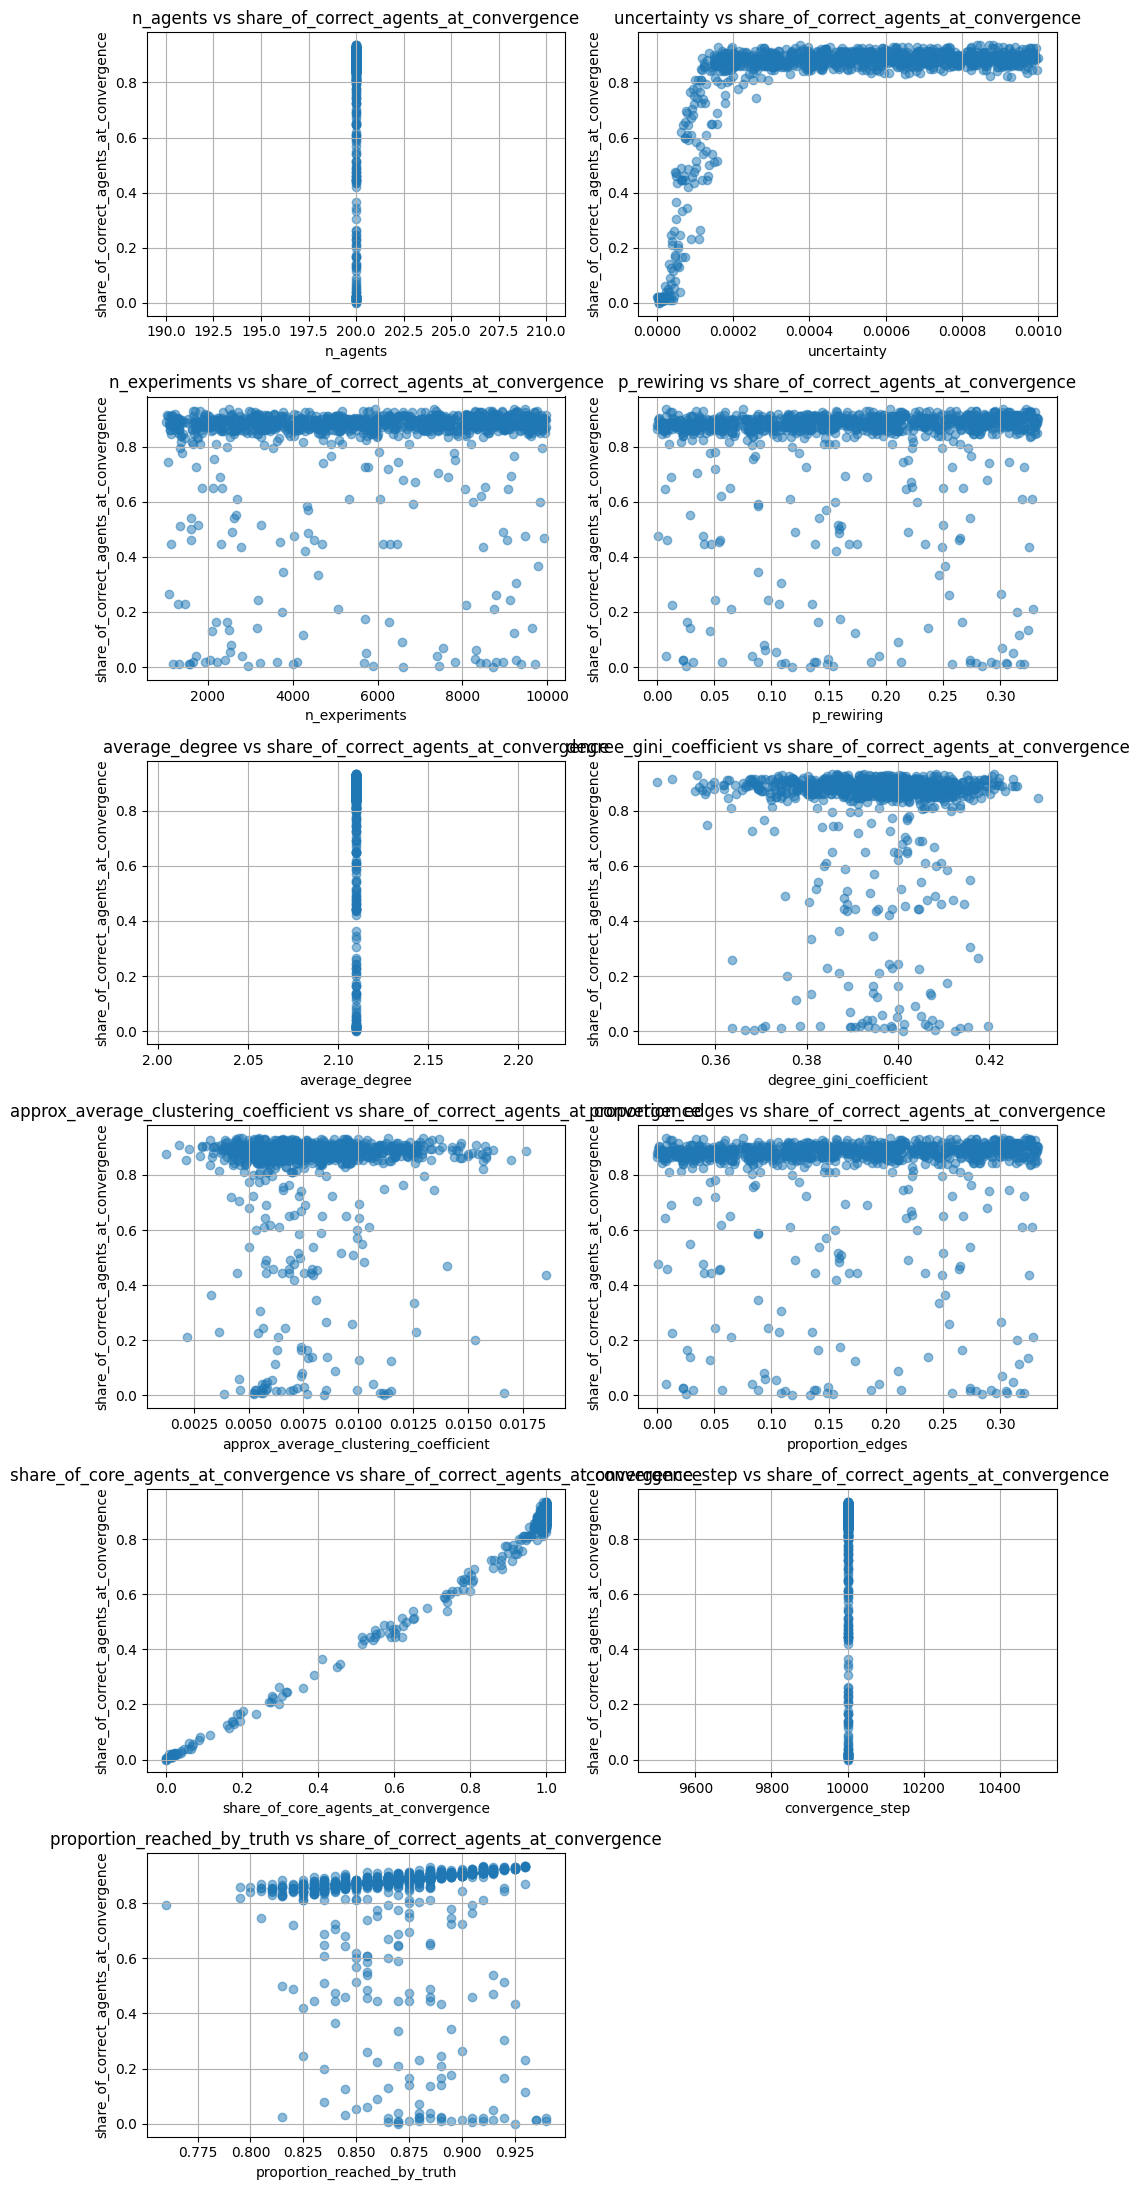

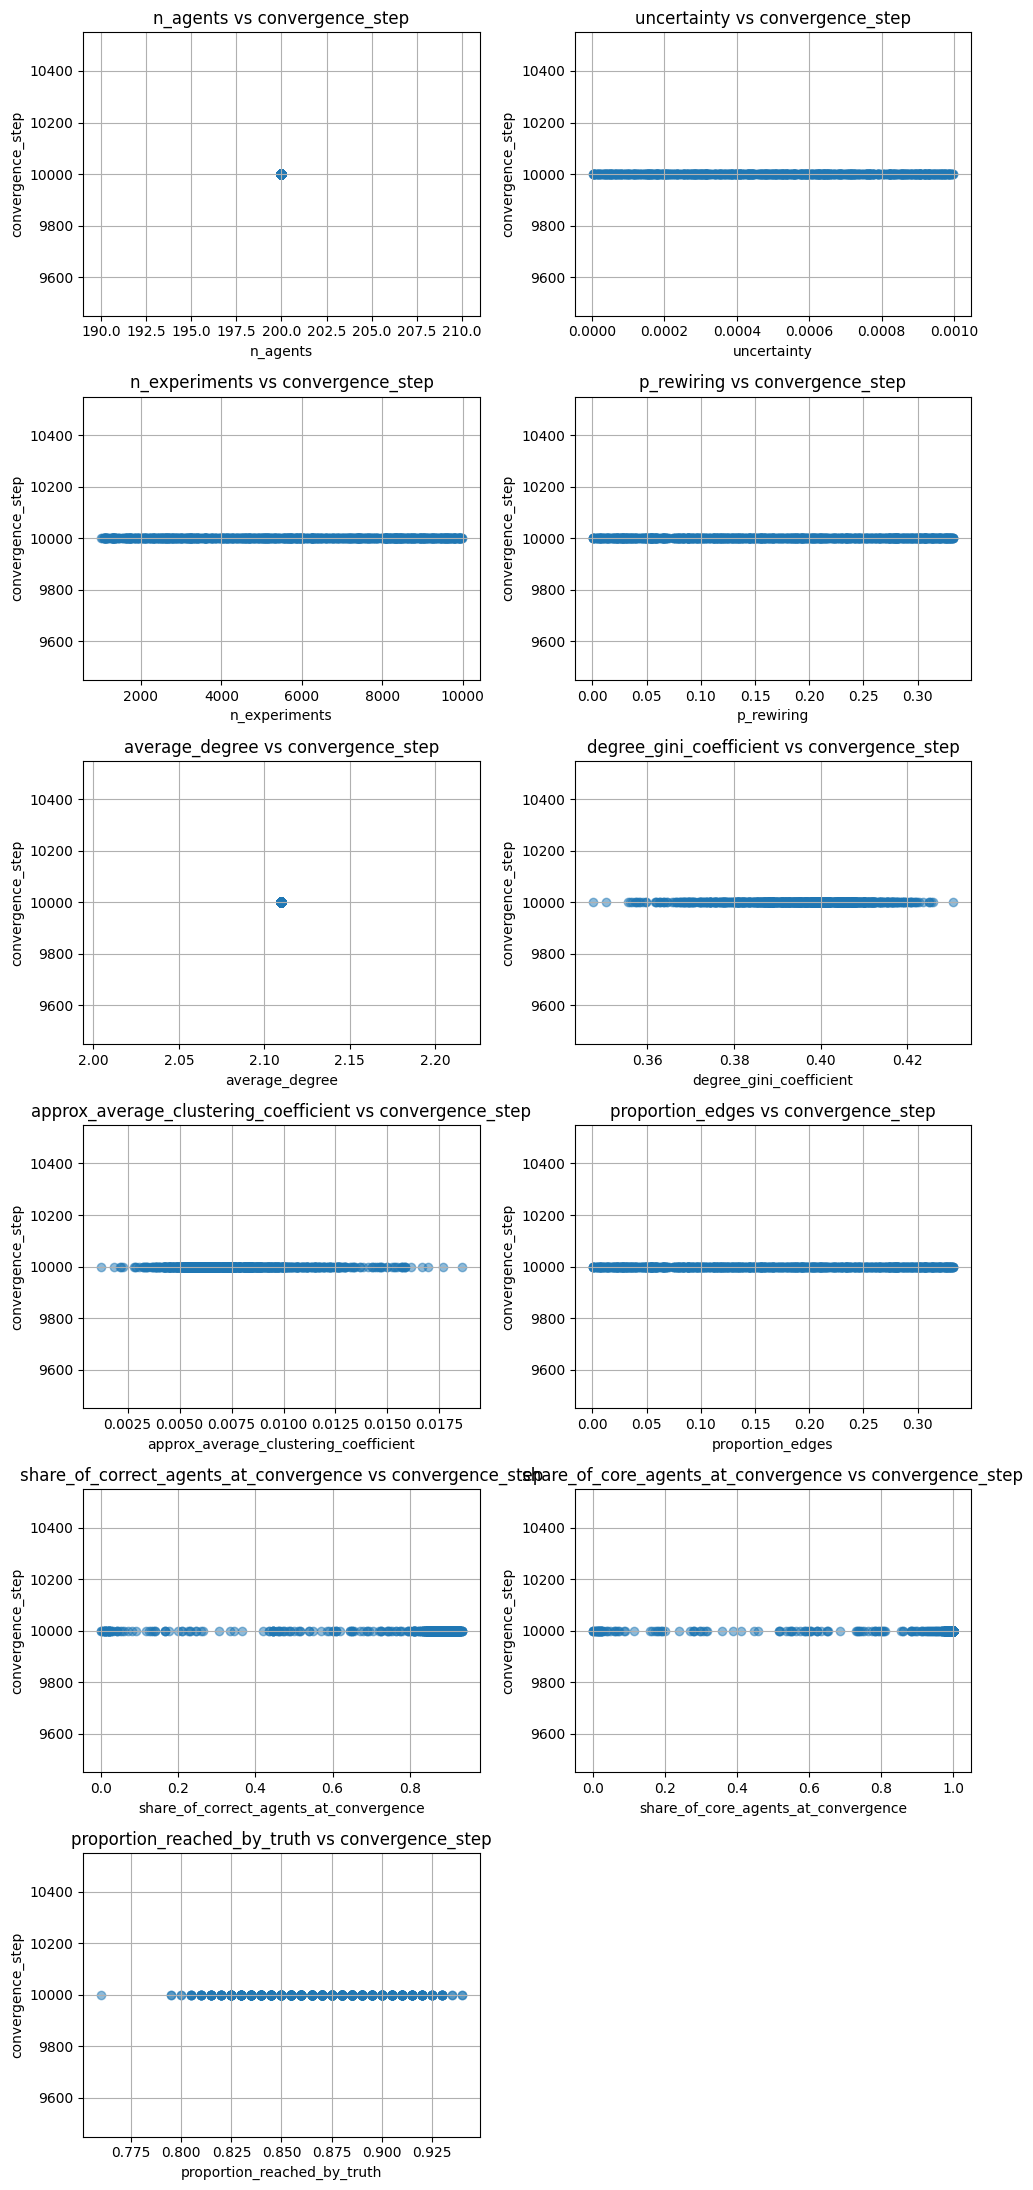



--- Plotting Phase Complete ---


In [ ]:

# Run each method in isolation
# Using a main guard for multiprocessing safety
if __name__ == '__main__':
    nonvect_main(combine_results=False,agent_type='bayes',n_simulations = 1000)
    run_plotting(vectorized=False) # Run plotting after main simulation

Number of cores: 24

--- Starting simulations for ER Network: er_n200_p0.01 ---


Running simulations for randomization: 100%|██████████| 1000/1000 [01:59<00:00,  8.40it/s]


Total results for randomization (er_n200_p0.01): 1000

--- Starting Plotting Phase ---
Loading results for: er_n200_p0.01 (randomization)
Loaded 1000 results from path: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/ignacio_playground/vectorized_er_n200_p0.01_results_randomization.csv.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   randomized                              1000 non-null   bool   
 1   unique_id                               1000 non-null   object 
 2   n_agents                                1000 non-null   int64  
 3   uncertainty                             1000 non-null   float64
 4   n_experiments                           1000 non-null   int64  
 5   p_rewiring                              1000 non-null   float64
 6   average_degree                 

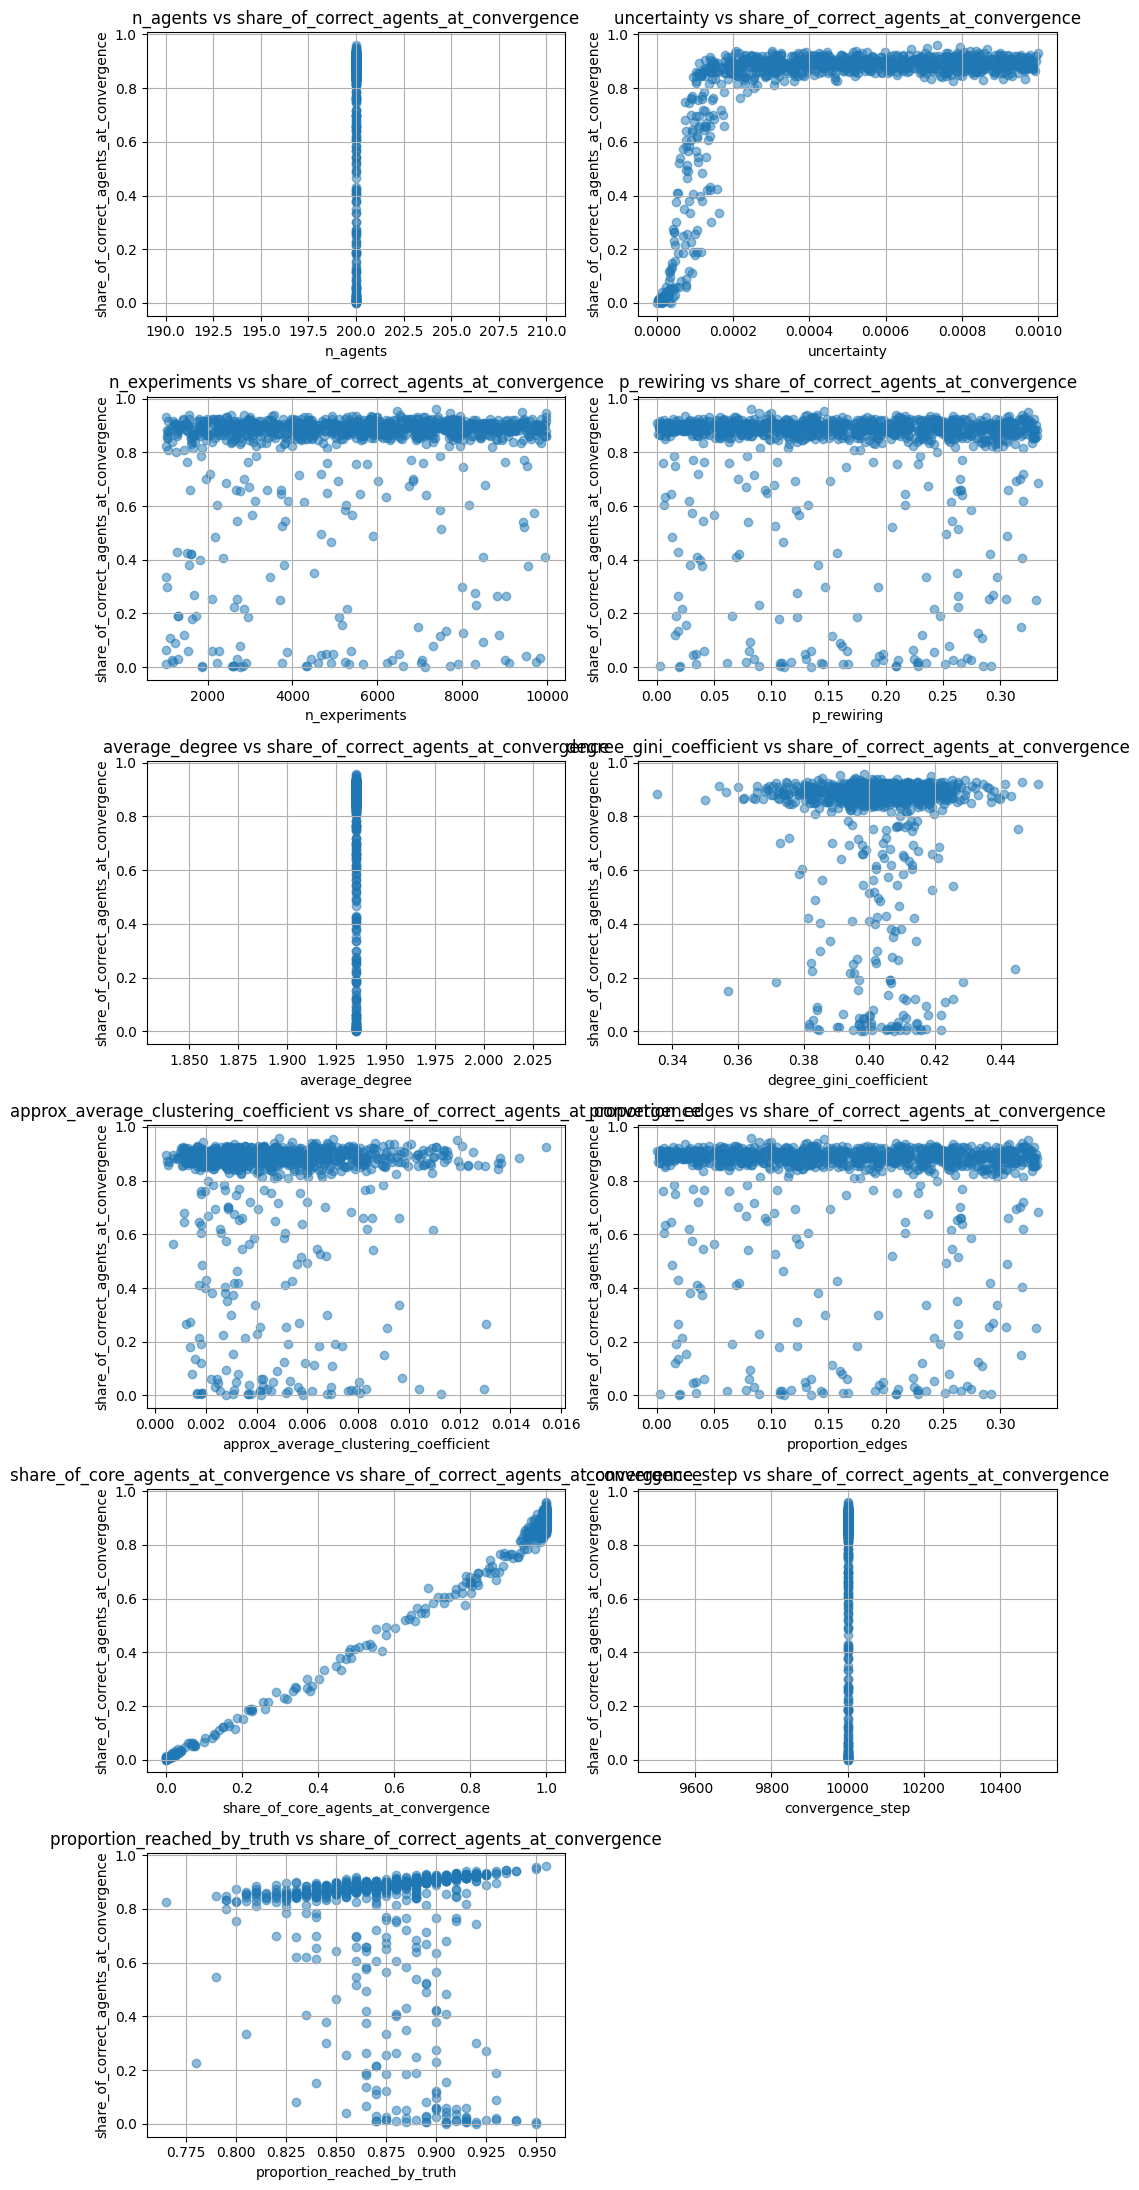

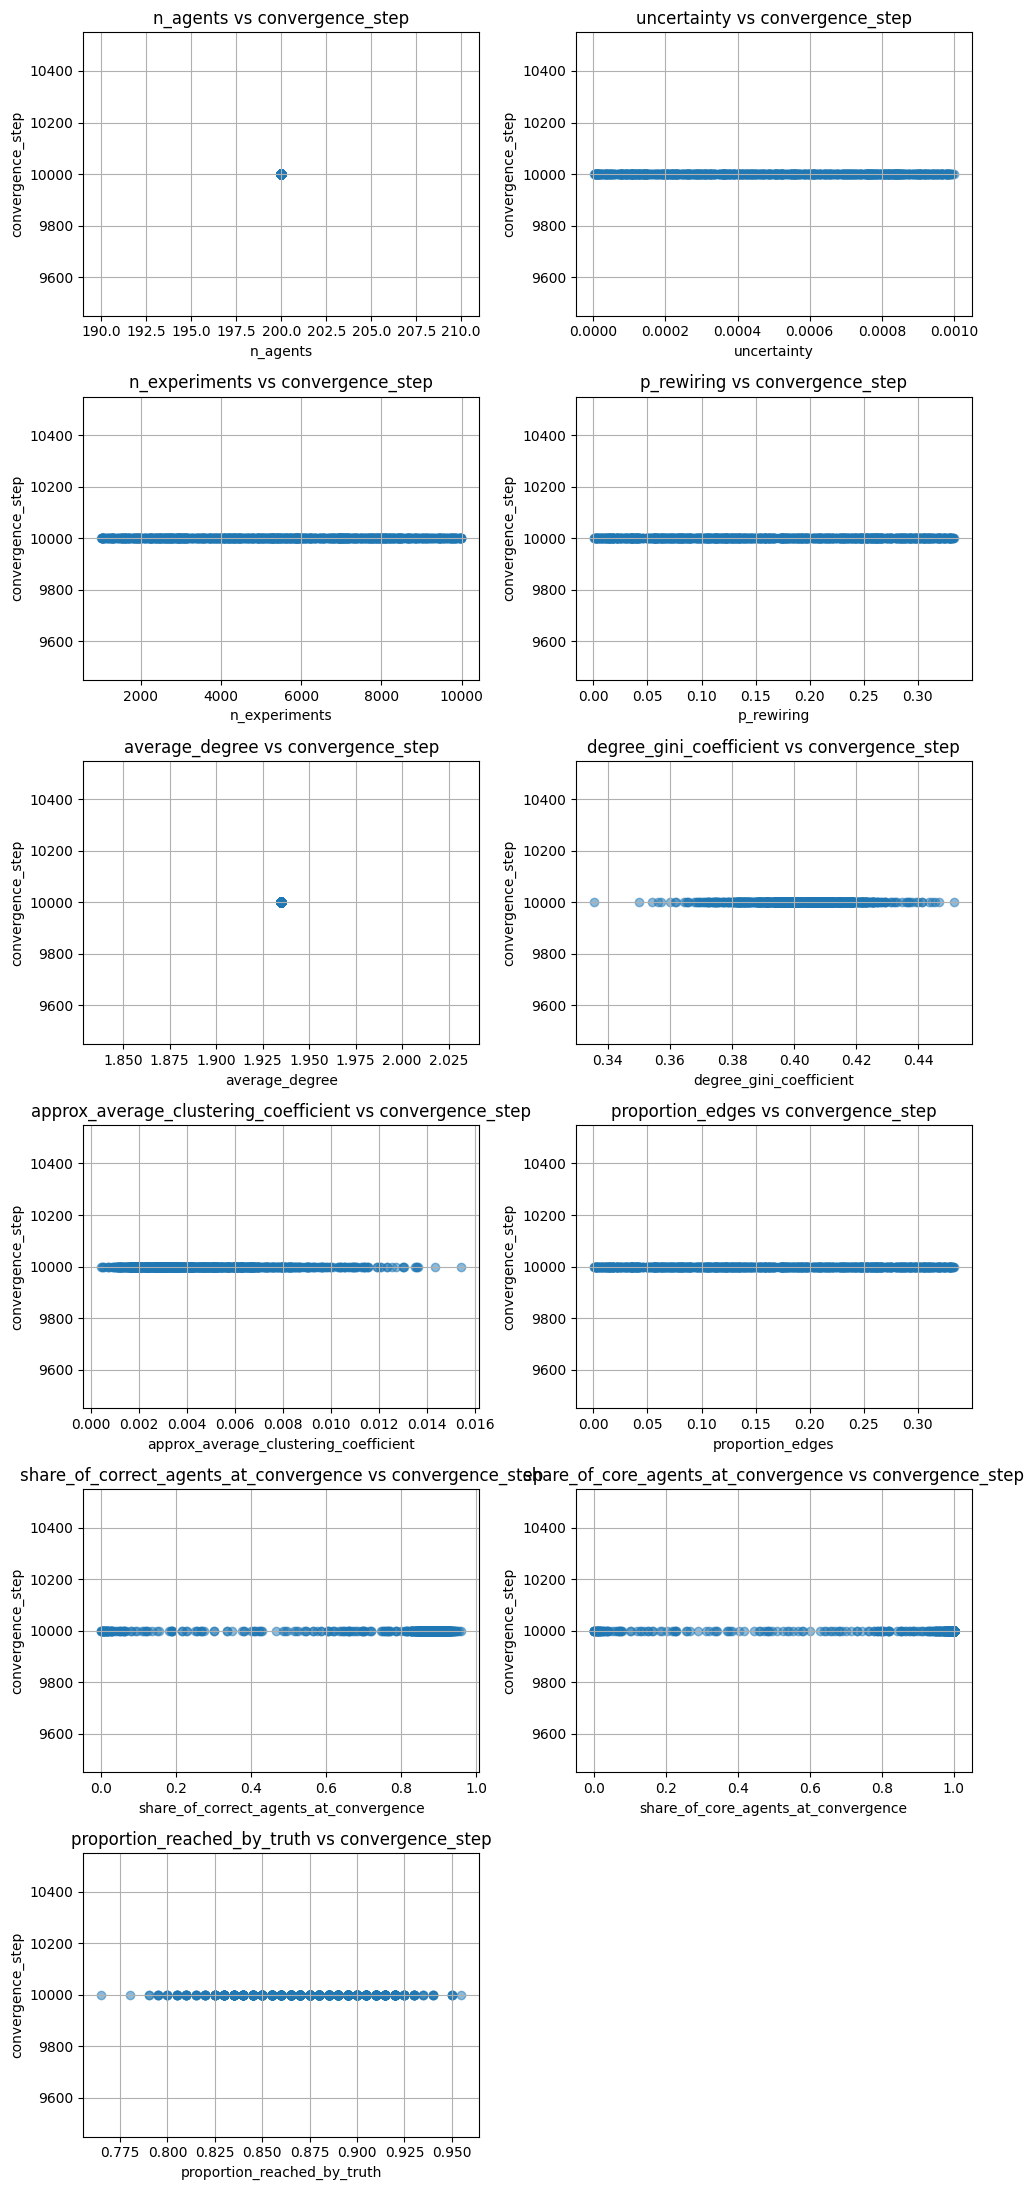



--- Plotting Phase Complete ---


In [ ]:
# Run each method in isolation
# Using a main guard for multiprocessing safety
if __name__ == '__main__':
    vect_main(combine_results=False,agent_type='bayes',n_simulations = 1000)
    run_plotting(vectorized=True) # Run plotting after main simulation

# Load Results and Plot them


--- Starting Plotting Phase ---
Loading results for: er_n200_p0.01 (randomization)
Loaded 1000 results from path: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/ignacio_playground/er_n200_p0.01_results_randomization.csv.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   randomized                              1000 non-null   bool   
 1   unique_id                               1000 non-null   object 
 2   n_agents                                1000 non-null   int64  
 3   uncertainty                             1000 non-null   float64
 4   n_experiments                           1000 non-null   int64  
 5   p_rewiring                              1000 non-null   float64
 6   average_degree                          1000 non-null   float64
 7   degree_gini_coefficient    

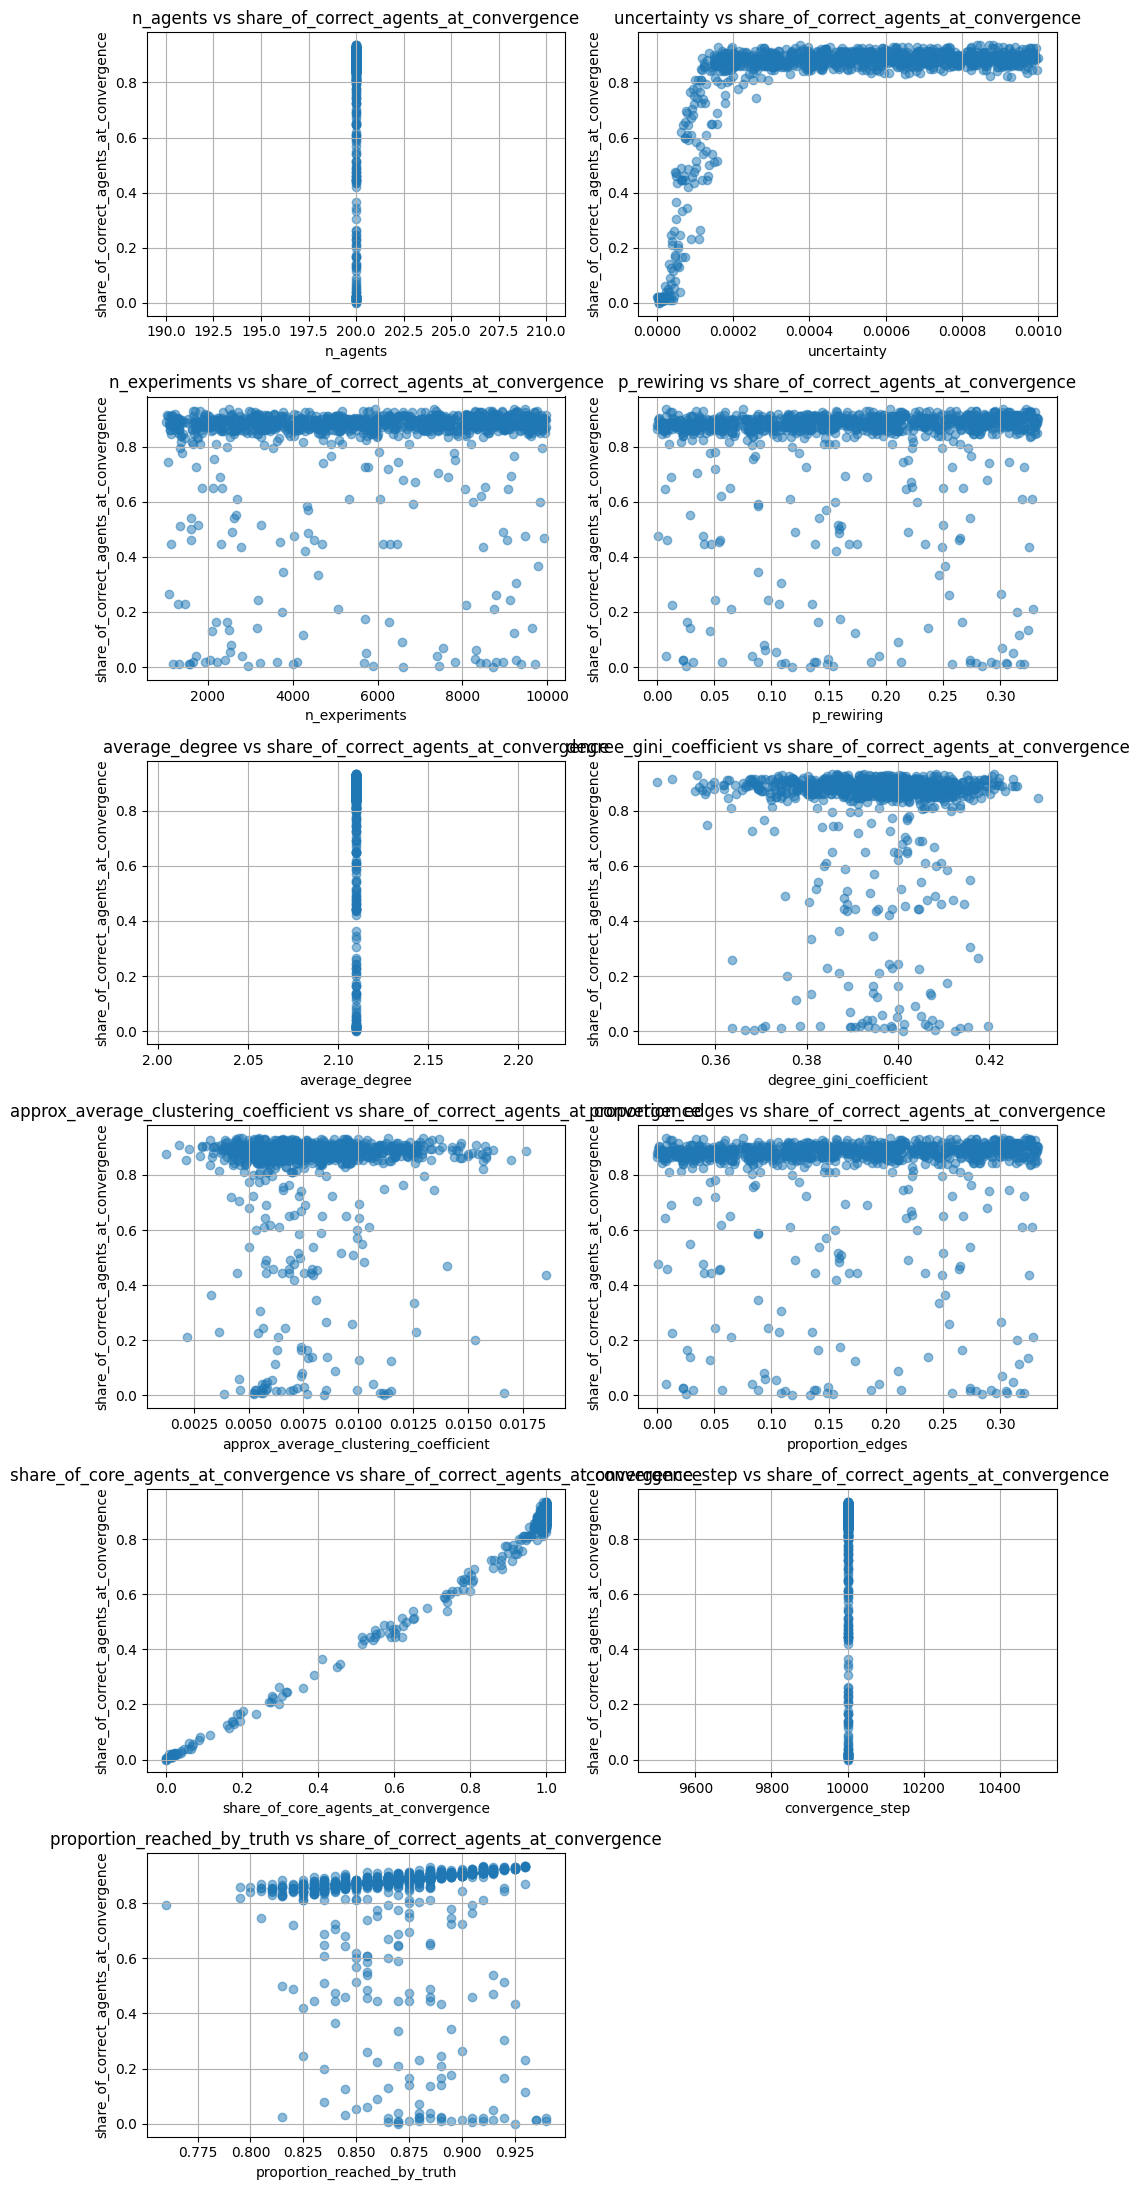

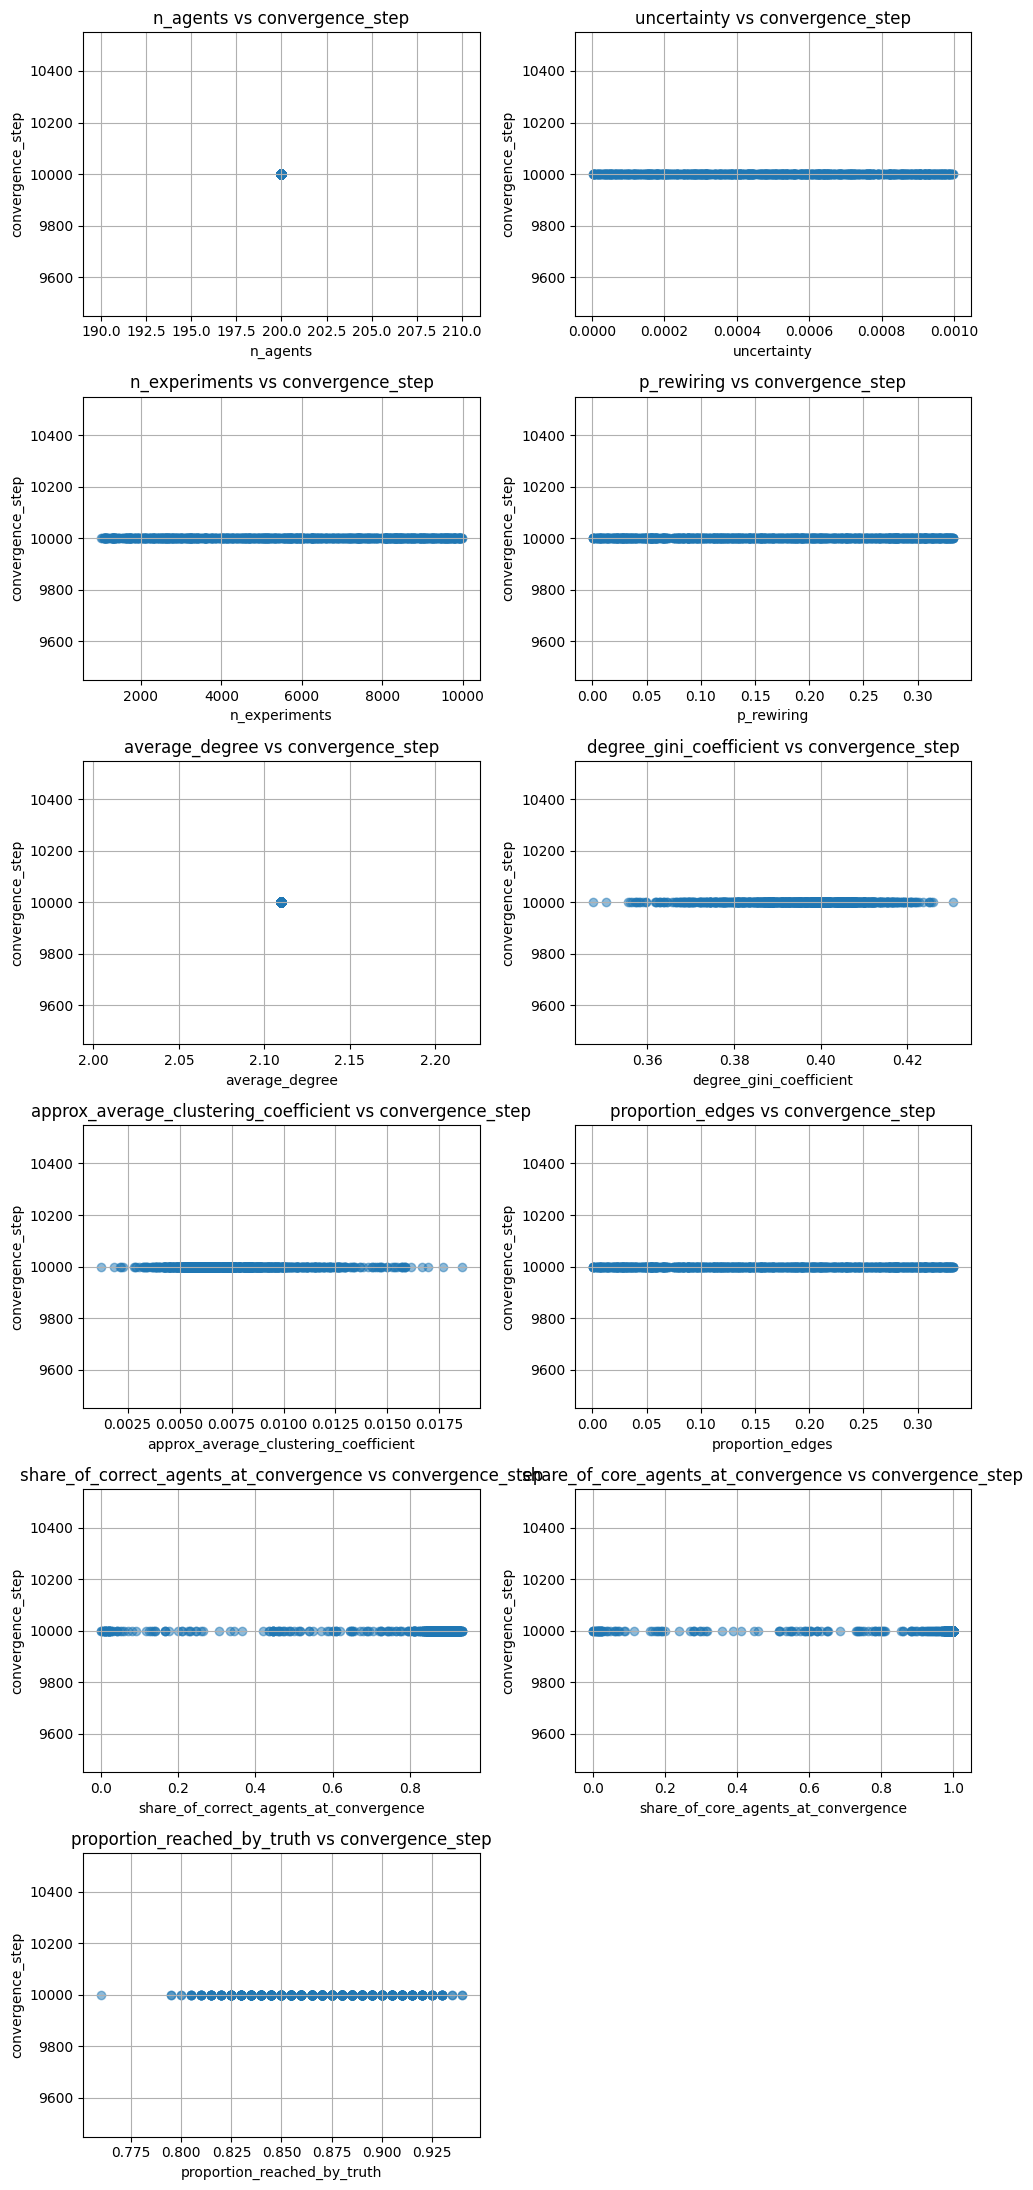



--- Plotting Phase Complete ---


In [ ]:
run_plotting(vectorized=False)


--- Starting Plotting Phase ---
Loading results for: er_n200_p0.01 (randomization)
Loaded 1000 results from path: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/ignacio_playground/vectorized_er_n200_p0.01_results_randomization.csv.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   randomized                              1000 non-null   bool   
 1   unique_id                               1000 non-null   object 
 2   n_agents                                1000 non-null   int64  
 3   uncertainty                             1000 non-null   float64
 4   n_experiments                           1000 non-null   int64  
 5   p_rewiring                              1000 non-null   float64
 6   average_degree                          1000 non-null   float64
 7   degree_gini_coef

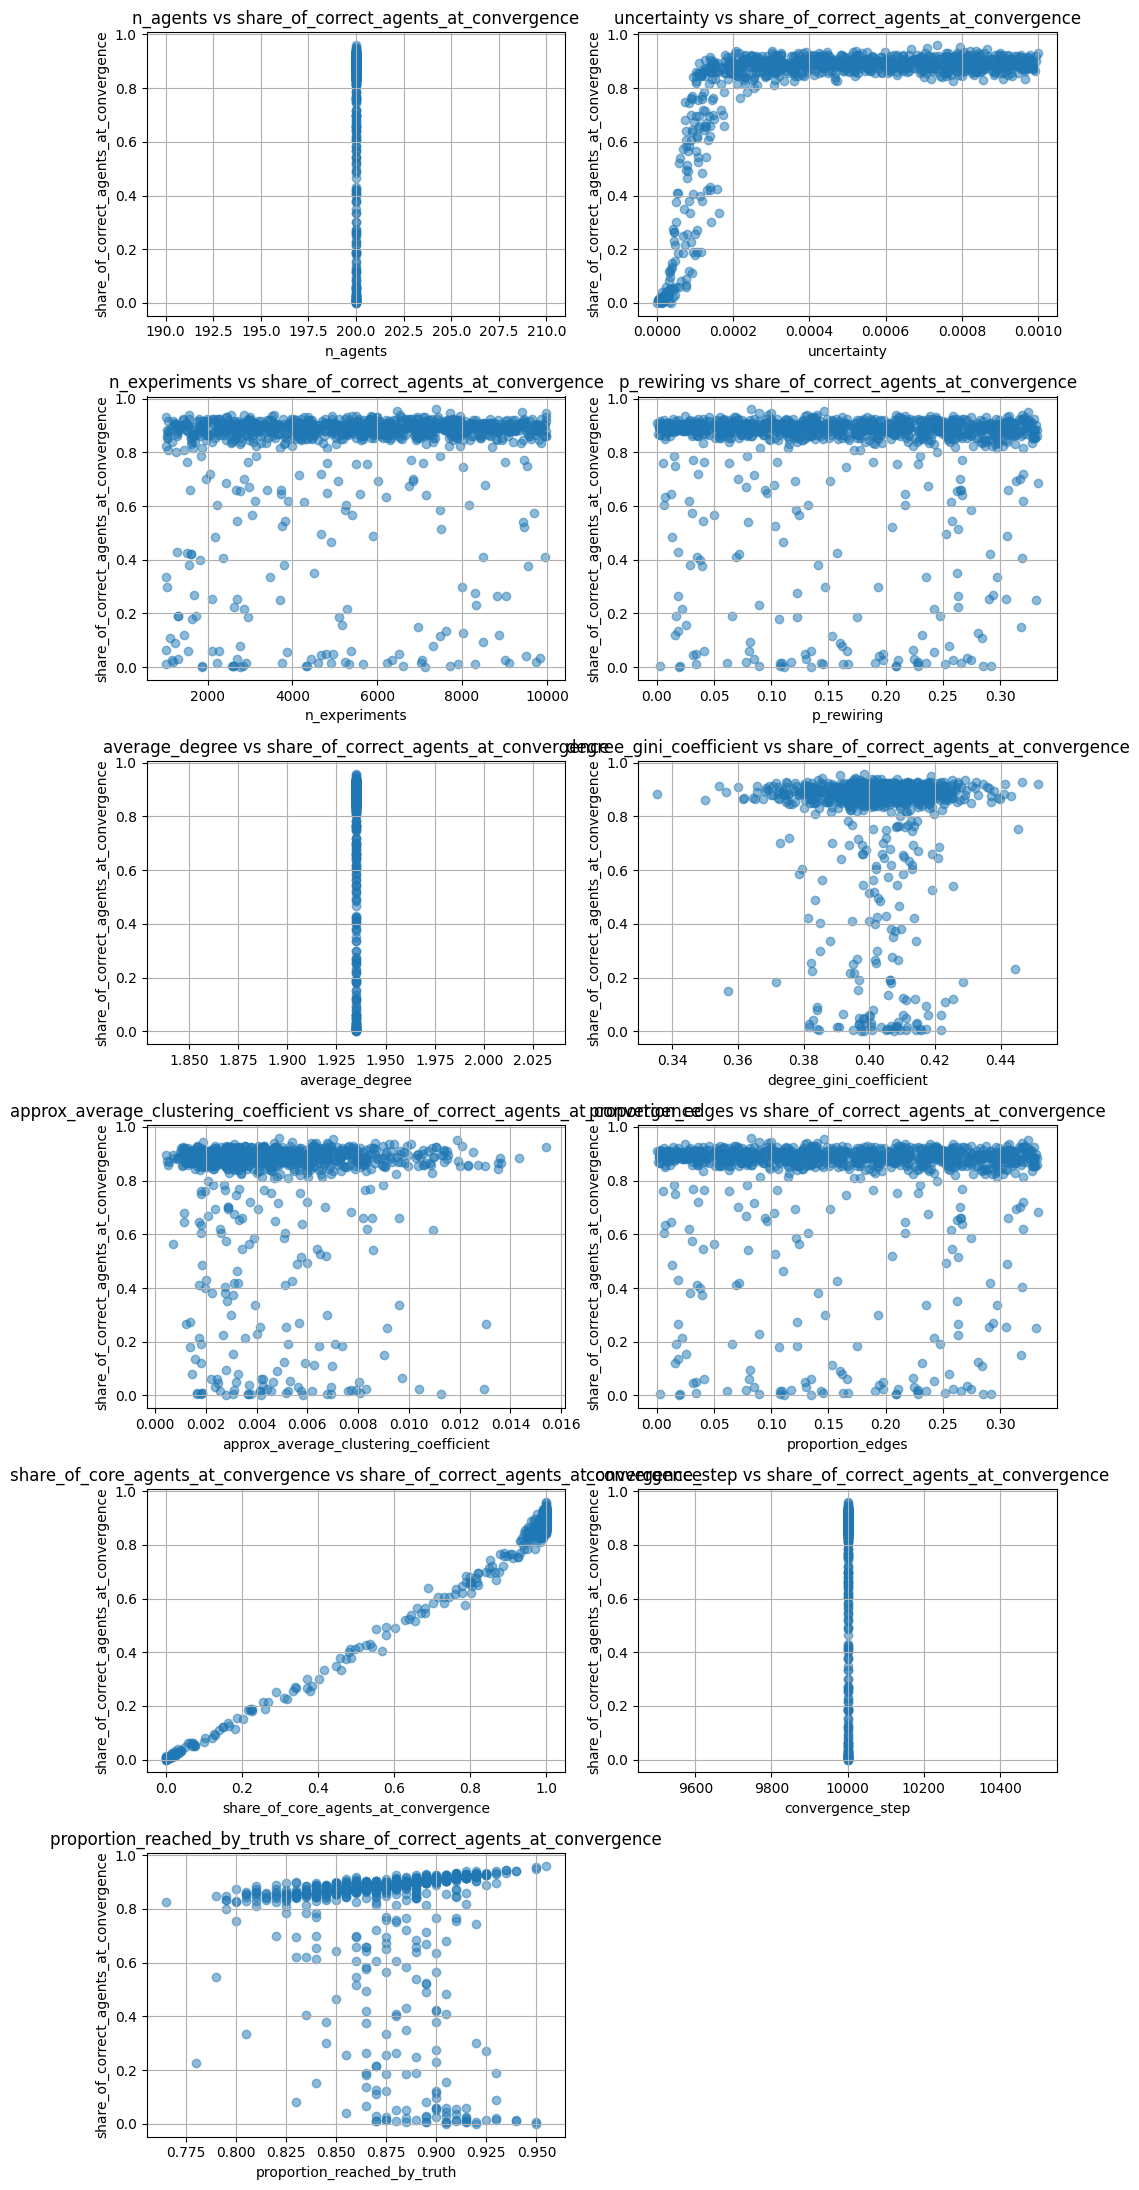

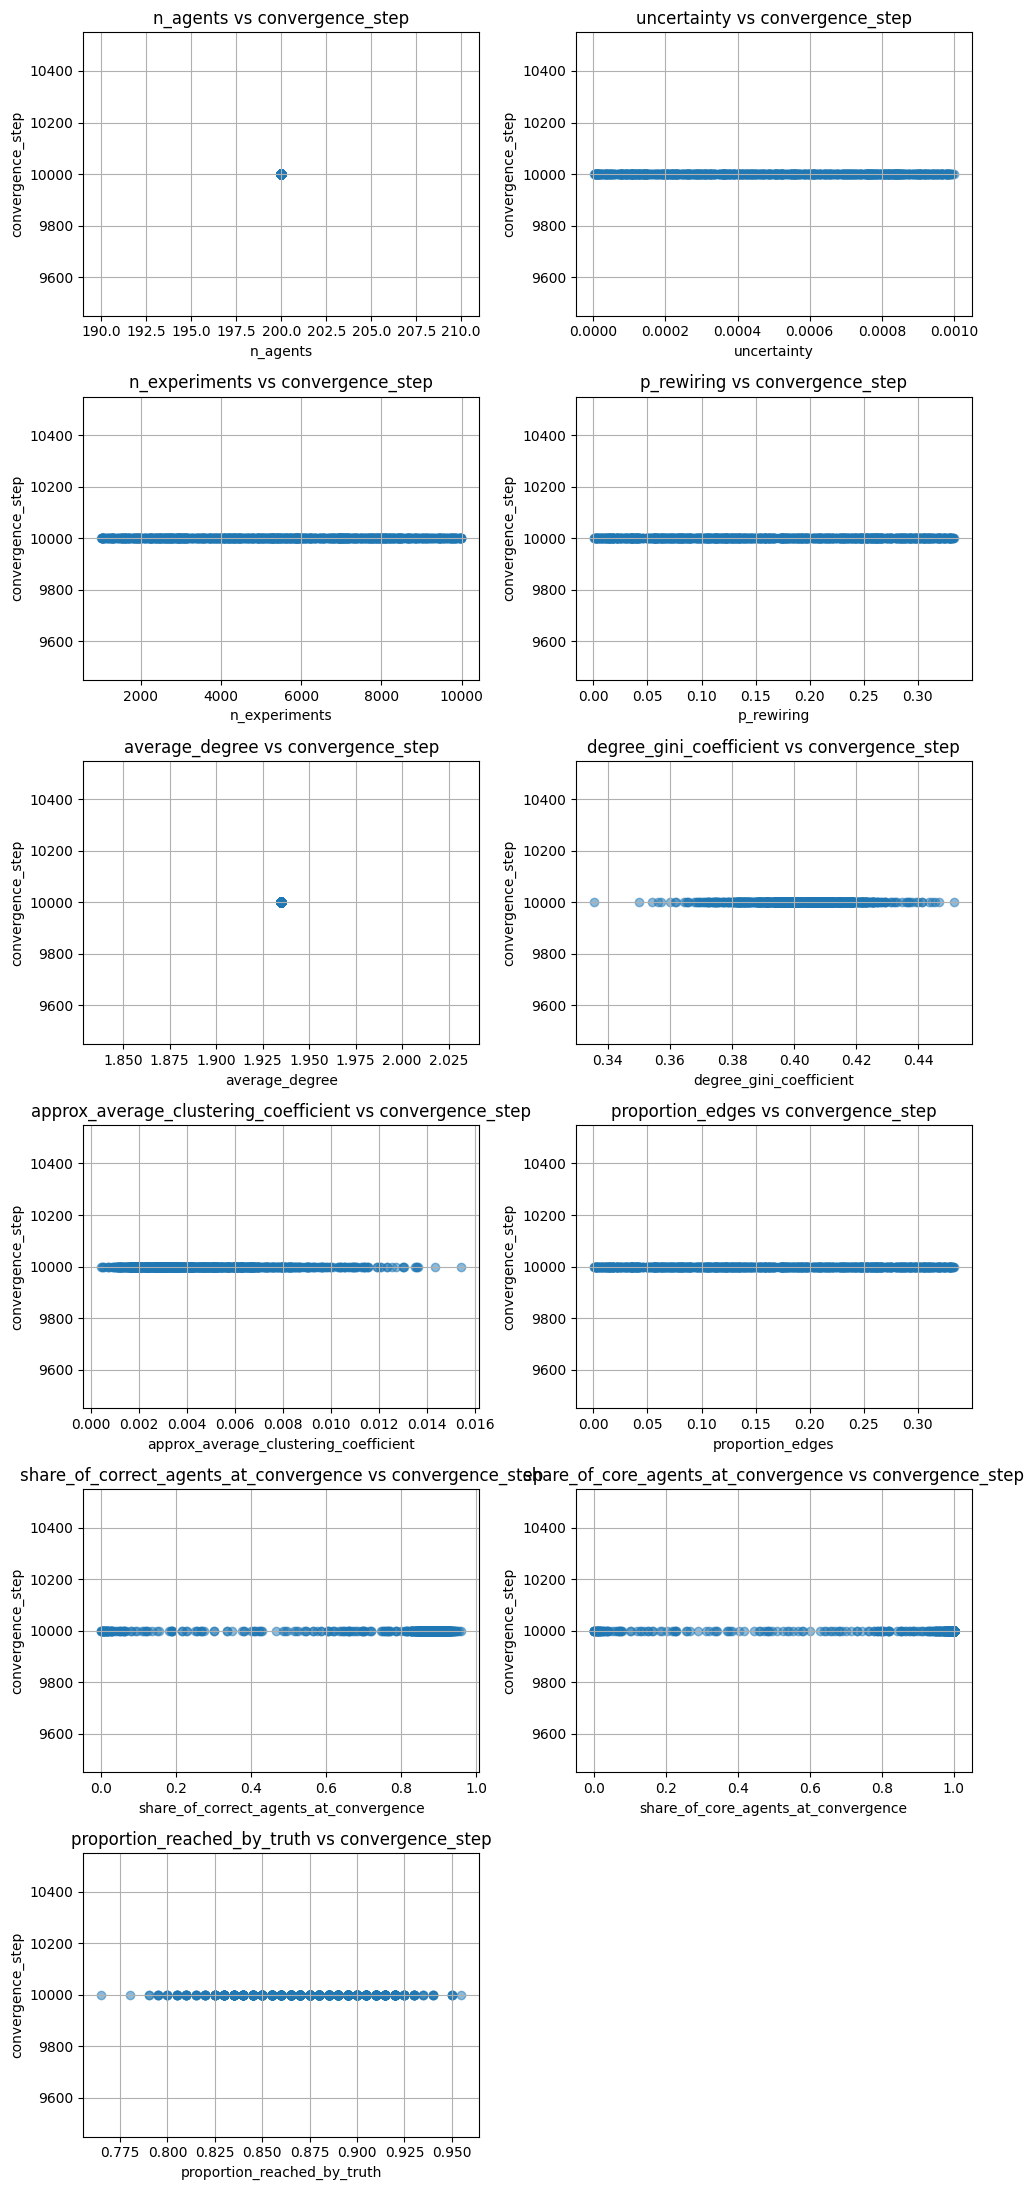



--- Plotting Phase Complete ---


In [ ]:
run_plotting(vectorized=True)

# Disconnect from Runtime

In [ ]:
from datetime import datetime
import pytz
from IPython.display import Javascript

# Get current time in New York
nyc_time = datetime.now(pytz.timezone('America/New_York'))
formatted_time = nyc_time.strftime('%Y-%m-%d %H:%M:%S %Z')

# Print and log
print(f"✅ Disconnected from runtime at: {formatted_time}")

# Disconnect Colab runtime
display(Javascript('google.colab.kernel.disconnect()'))

✅ Disconnected from runtime at: 2026-01-09 07:11:13 EST


<IPython.core.display.Javascript object>